# Final Project - Introduction to Programming Language


####Team Members:
##### Santiago Correa Maciel
##### Ashvin Jose
##### Diego Pablo Ramos Martínez

### Project Overview
#### The dataset from Kaggle captures the intricate relationship between an individual's social media habits and their mental well-being. It is designed for analysis tasks such as regression, correlation, or mental health prediction.
#### The main goal of our project is to use this data to study how lifestyle and online activity patterns influence human emotions and overall wellness.


## Dataset Description
####Key variables in the dataset include metrics such as:
#####Age
#####Gender
#####Daily screen time (in hours)
#####Sleep quality (on a 1-10 scale)
#####Stress level (on a 1-10 scale)
#####Days without social media (digital detox)
#####Exercise Frequency (days per week)
#####Most used social media platform
#####Happiness index (on a 1-10 scale)

##DATA LOADING — Import & Preview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_excel = pd.read_excel("/content/Mental_Health_and_Social_Media_Balance_Dataset.xlsx")
print("First 5 rows:")
display(df_excel.head())

print("\nDataset info:")
df_excel.info()
df_excel.shape

print("\nStatistical Summary:")
display(df_excel.describe())

First 5 rows:


,L,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7,6,2,5,Facebook,10
1,U002,30,Other,5.1,7,8,5,3,LinkedIn,10
2,U003,23,Other,7.4,6,7,1,3,YouTube,6
3,U004,36,Female,5.7,7,8,1,1,TikTok,8
4,U005,34,Female,7.0,4,7,5,1,X (Twitter),8



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0    L                         500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    int64  
 5   Stress_Level(1-10)         500 non-null    int64  
 6   Days_Without_Social_Media  500 non-null    int64  
 7   Exercise_Frequency(week)   500 non-null    int64  
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 39.2+ KB

Statistical Summary:


,Age,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,32.988000,5.530000,6.304000,6.618000,3.134000,2.448000,8.376000
std,9.960637,1.734877,1.529792,1.542996,1.858751,1.428067,1.524228
min,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,4.000000
25%,24.000000,4.300000,5.000000,6.000000,2.000000,1.000000,7.000000
50%,34.000000,5.600000,6.000000,7.000000,3.000000,2.000000,9.000000
75%,41.000000,6.700000,7.000000,8.000000,5.000000,3.000000,10.000000
max,49.000000,10.800000,10.000000,10.000000,9.000000,7.000000,10.000000


##DATA PREPARATION — Cleaning & Preparation

In [ ]:
# Rename columns for easier coding
df = df_excel.rename(columns={
    "Daily_Screen_Time(hrs)": "Screen_Time",
    "Sleep_Quality(1-10)": "Sleep_Quality",
    "Stress_Level(1-10)": "Stress_Level",
    "Days_Without_Social_Media": "Days_Without_SM",
    "Exercise_Frequency(week)": "Exercise_Freq",
    "Happiness_Index(1-10)": "Happiness"
})

# Check missing values
print("Missing values:")
print(df.isna().sum())

# If missing values exist, fill them
df["Screen_Time"] = df["Screen_Time"].fillna(df["Screen_Time"].mean())
df["Sleep_Quality"] = df["Sleep_Quality"].fillna(df["Sleep_Quality"].median())
df["Stress_Level"] = df["Stress_Level"].fillna(df["Stress_Level"].median())
df["Days_Without_SM"] = df["Days_Without_SM"].fillna(df["Days_Without_SM"].median())
df["Exercise_Freq"] = df["Exercise_Freq"].fillna(df["Exercise_Freq"].median())
df["Happiness"] = df["Happiness"].fillna(df["Happiness"].median())

# Convert numeric columns
numeric_cols = ["Age","Screen_Time","Sleep_Quality","Stress_Level","Days_Without_SM","Exercise_Freq","Happiness"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print("\nCleaned dataset:")
display(df.head())

Missing values:
 L                       0
Age                      0
Gender                   0
Screen_Time              0
Sleep_Quality            0
Stress_Level             0
Days_Without_SM          0
Exercise_Freq            0
Social_Media_Platform    0
Happiness                0
dtype: int64

Cleaned dataset:


,L,Age,Gender,Screen_Time,Sleep_Quality,Stress_Level,Days_Without_SM,Exercise_Freq,Social_Media_Platform,Happiness
0,U001,44,Male,3.1,7,6,2,5,Facebook,10
1,U002,30,Other,5.1,7,8,5,3,LinkedIn,10
2,U003,23,Other,7.4,6,7,1,3,YouTube,6
3,U004,36,Female,5.7,7,8,1,1,TikTok,8
4,U005,34,Female,7.0,4,7,5,1,X (Twitter),8


The Database does not contain any empty values, which allows its analysis to be easier and more efficient. Nevertheless, a cleaning was performed anyways to establish our methodolgy.

1. The majority of key variables would be replaced by their median due to their lack of symmetry, non-ordinal distribution, or being subject to extreme values which directly affect their average.

2. Screen Time is the only value which uses its mean to represent average users due to its ordinal distribution (although still subject to extreme values).

##PROGRAMMING LOGIC — Loops, Conditionals & Functions

#### Function to classify screen time

In [ ]:
def classify_screen_time(hours):
    if hours <= 3:
        return "Low"
    elif hours <= 6:
        return "Moderate"
    else:
        return "High"

df["Screen_Time_Category"] = df["Screen_Time"].apply(classify_screen_time)

This function sets the conditionals to categorize user's screen time in 3 efficient and comprehensible rubrics: (0 < 3 hours) Low, (4 < 6) Moderate, and  (7 <) High.

#### Loop to count users per screen-time category

In [ ]:
category_counts = {"Low": 0, "Moderate": 0, "High": 0}

for cat in df["Screen_Time_Category"]:
    category_counts[cat] += 1

print("\nUsers per Screen Time Category:")
print(category_counts)


Users per Screen Time Category:
{'Low': 40, 'Moderate': 256, 'High': 204}


This code works to display the previously categories for the screen time key variable. Through a loop, the code adds 1 value when detecting its belonging to each category. In the end, allowing to see the total for each label.

####Conditional: Flag high and relatively high stress users

In [ ]:
df["High_Stress"] = df["Stress_Level"].apply(lambda x: 1 if x >= 8 else 0)
df["Moderately_High_Stress"] = df["Stress_Level"].apply(lambda x: 1 if x == 7 and x >= 6 else 0)
df["SMiddle_Point"] = df["Stress_Level"].apply(lambda x: 1 if x == 5 else 0)

print("\nNumber of High Stress Users:", df["High_Stress"].sum())
print("Number of Moderately High Stress Users:", df["Moderately_High_Stress"].sum())
print("Number of Middle Point Users:", df["SMiddle_Point"].sum())


Number of High Stress Users: 143
Number of Moderately High Stress Users: 129
Number of Middle Point Users: 76


This code helps to establish the categories for stress level in users to be considered as high through a lambda function which sums a value into the defined variable when a condition is met (e.g. if x > 8 the user is considered to be highly stressed). Then the categories are displayed with their total counts.

In [ ]:
df["High_Happiness"] = df["Happiness"].apply(lambda x: 1 if x >= 8 else 0)
df["Moderate_Happiness"] = df["Happiness"].apply(lambda x: 1 if x == 7 and x >= 6 else 0)
df["HMiddle_Point"] = df["Happiness"].apply(lambda x: 1 if x == 5 else 0)

print("\nNumber of Highly Happy Users:", df["High_Happiness"].sum())
print("Number of Moderately Happy Users:", df["Moderate_Happiness"].sum())
print("Number of Middle Point Users:", df["HMiddle_Point"].sum())


Number of Highly Happy Users: 362
Number of Moderately Happy Users: 76
Number of Middle Point Users: 16


This code defines the number of users which are among the "Highly Happy" and "Moderatley Happy" categories using lambda functions with conditionals to establish the range of each metric. These functions are exactly equal to the ones defined for "Stress_Level" in order to have a better approximation to the association of them with the "Scree_Time" variable.

Function to calculate average happiness by platform

In [ ]:
def avg_happiness_by_platform(platform):
    platform_data = df[df["Social_Media_Platform"] == platform]
    return platform_data["Happiness"].mean()

platforms = df["Social_Media_Platform"].unique()

print("\nAverage Happiness by Platform:")
for p in platforms:
    print(p, ":", round(avg_happiness_by_platform(p), 2))



Average Happiness by Platform:
Facebook : 8.35
LinkedIn : 8.52
YouTube : 8.31
TikTok : 8.38
X (Twitter) : 8.65
Instagram : 7.99


The function defines the social media platforms which generate the most happiness in average into their users. The top is X(Twitter) with a mean of 8.65. On the other hand, Instagram has the lowest happiness index with 7.99

Data Visualization

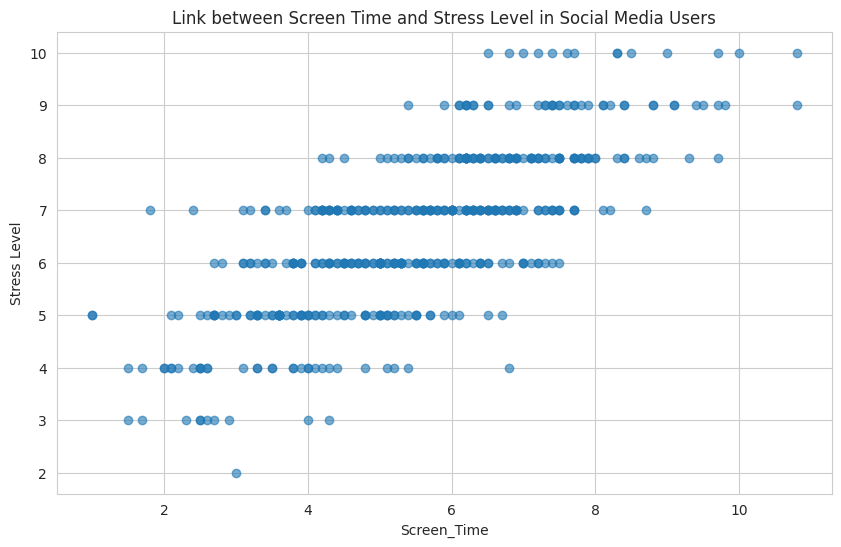

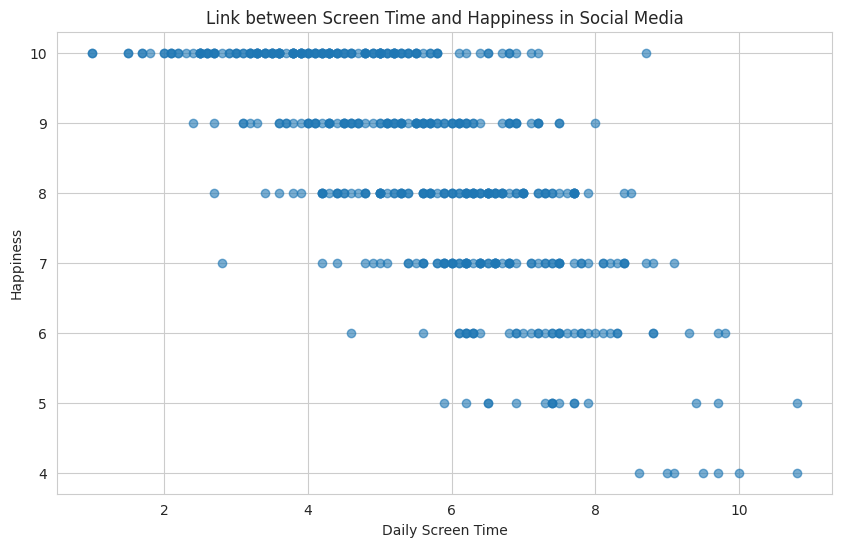

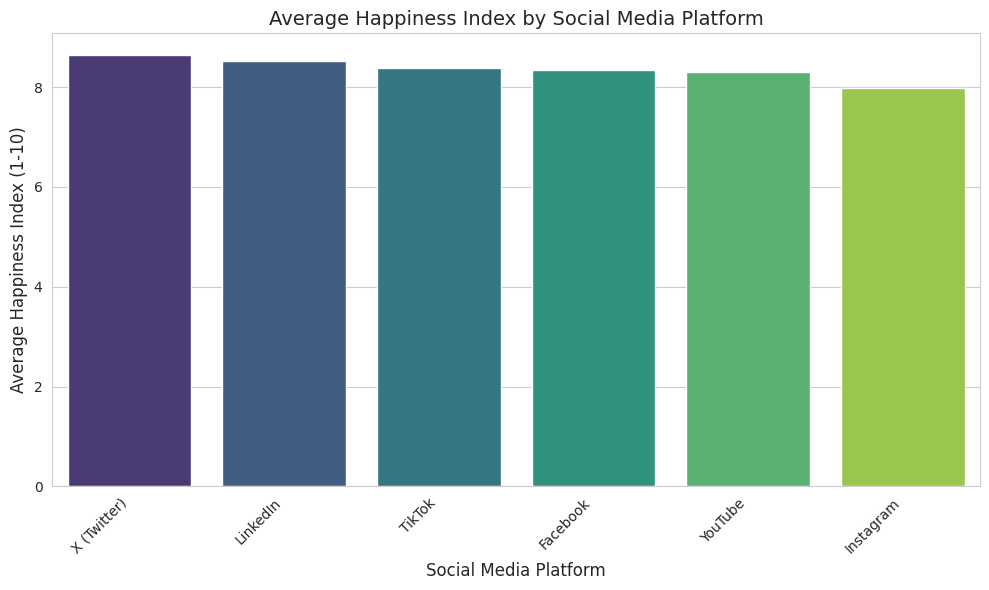

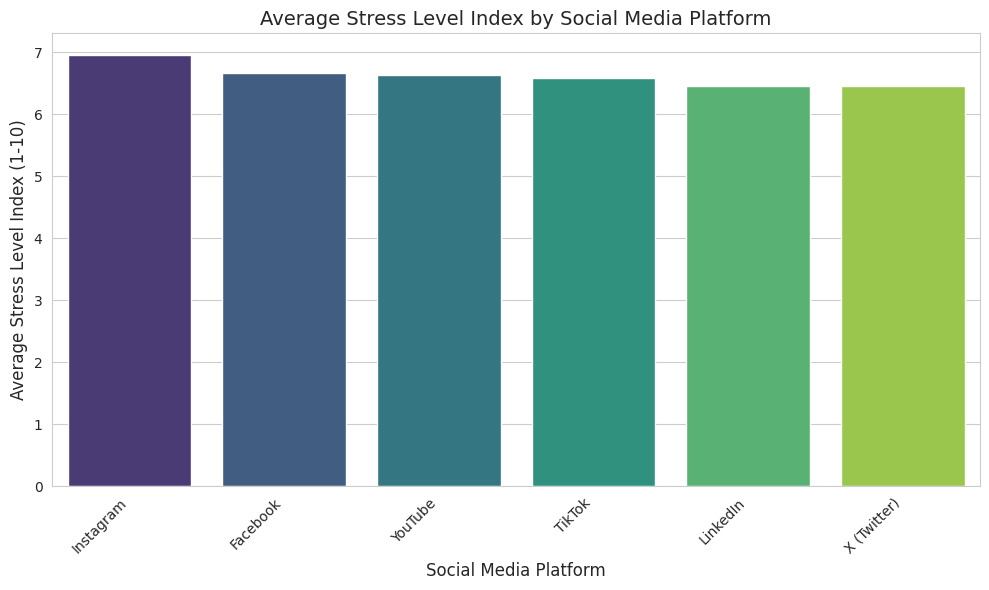

In [ ]:
sns.set_style("whitegrid")

#1. Relationship between Screen Time & Stress Level
plt.figure(figsize=(10,6))
plt.scatter(
    df["Screen_Time"],
    df["Stress_Level"],
    alpha = 0.6)
plt.title("Link between Screen Time and Stress Level in Social Media Users")
plt.xlabel("Screen_Time")
plt.ylabel("Stress Level")
plt.show()


#2. Relationship between Screen Time & Happiness
plt.figure(figsize=(10,6))
plt.scatter(
    df["Screen_Time"],
    df["Happiness"],
    alpha = 0.6)
plt.title("Link between Screen Time and Happiness in Social Media")
plt.xlabel("Daily Screen Time")
plt.ylabel("Happiness")
plt.show()


#3. Bar Plot for Average Happiness Index by Social Media Platform ---
plt.figure(figsize=(10, 6))
# Using the new 'Happiness' column name
platform_happiness = df.groupby('Social_Media_Platform')['Happiness'].mean().sort_values(ascending=False).reset_index()
sns.barplot(
    x='Social_Media_Platform',
    y='Happiness',
    data=platform_happiness,
    palette='viridis',
    # Explicitly setting hue to suppress the FutureWarning
    hue='Social_Media_Platform')
# Removed the line to manually remove legend as it causes the error when no legend is created
plt.title('Average Happiness Index by Social Media Platform', fontsize=14)
plt.xlabel('Social Media Platform', fontsize=12)
plt.ylabel('Average Happiness Index (1-10)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('platform_vs_average_happiness_bar_final.png')
plt.show()


#4. Bar Plot for Average Stress Level Index by Social Media Platform ---
plt.figure(figsize=(10, 6))
# Using the new 'Stress Level' column name
platform_happiness = df.groupby('Social_Media_Platform')['Stress_Level'].mean().sort_values(ascending=False).reset_index()
sns.barplot(
    x='Social_Media_Platform',
    y='Stress_Level',
    data=platform_happiness,
    palette='viridis',
    # Explicitly setting hue to suppress the FutureWarning
    hue='Social_Media_Platform')
# Removed the line to manually remove legend as it causes the error when no legend is created
plt.title('Average Stress Level Index by Social Media Platform', fontsize=14)
plt.xlabel('Social Media Platform', fontsize=12)
plt.ylabel('Average Stress Level Index (1-10)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('platform_vs_average_Stress_Level_bar_final.png')
plt.show()

The first 2 graphs display in a clearer way the positive correlation between screen time and stress level and the decrease of happiness as screen time rises. Both scatter plots allow a clear location of the variables and their established categories in order to make a qualitative analysis.

Secondly, the happiness and stress levels per platform data is also displayed into a polished and concise bar chart that uses sns to show a clearer image of the platforms influence in users' happiness and stress levels.

**Conclusion**
By using basic and intermediary Python knowledge, our team was able to apply tools in a database around mental health and social media, and develop correlations between specific key variables: the positive link between highly users' screen time and increasing stress levels; the decrease of happiness as screen time increases; and the social media platforms which generete the most happiness for digital customers. These metrics may be used for future decision making in order to create healthier online environments and usage.